In [24]:
import pandas as pd
import os
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import numpy as np
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
import xgboost as xgb
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor

In [17]:
PROJECT_DIR = r"D:\JMM_Technologies\CryptoCurrency-Forecasting\ML\data\processed_data"

In [18]:
def get_data(name):
	file_name = f"{name}.csv"
	file_path = os.path.join(PROJECT_DIR, file_name)
	return pd.read_csv(file_path)

In [19]:
df = get_data('bitcoin_processed')

In [20]:
df['average_price'] = (df['high'] + df['low']) / 2

In [12]:
df = df.drop(columns=['volume', 'taker_buy_base_asset_volume'])

In [67]:
df.head()

,open,high,low,close,quote_asset_volume,number_of_trades,taker_buy_quote_asset_volume,average_price,price_change,target_close,close_to_open
0,19312.24,19395.91,18920.35,19056.80,3.970725e+09,3320217,1.977186e+09,19158.13,-255.44,19629.08,-255.44
1,19057.74,19719.10,18959.68,19629.08,5.672106e+09,4471910,2.847847e+09,19339.39,571.34,20337.82,571.34
2,19629.08,20475.00,19490.60,20337.82,6.533428e+09,4871932,3.309936e+09,19982.80,708.74,20158.26,708.74
3,20337.82,20365.60,19730.00,20158.26,6.275437e+09,4540004,3.120339e+09,20047.80,-179.56,19960.67,-179.56
4,20158.26,20456.60,19853.00,19960.67,6.452892e+09,5085004,3.256881e+09,20154.80,-197.59,19530.09,-197.59


<Axes: >

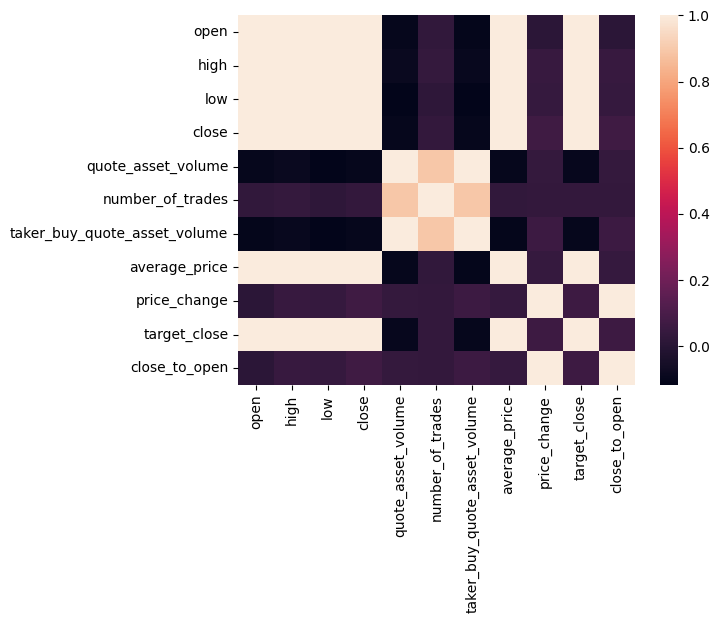

In [46]:
sns.heatmap(df.corr())

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 856 entries, 0 to 855
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   open                          856 non-null    float64
 1   high                          856 non-null    float64
 2   low                           856 non-null    float64
 3   close                         856 non-null    float64
 4   volume                        856 non-null    float64
 5   quote_asset_volume            856 non-null    float64
 6   number_of_trades              856 non-null    int64  
 7   taker_buy_base_asset_volume   856 non-null    float64
 8   taker_buy_quote_asset_volume  856 non-null    float64
 9   average_price                 856 non-null    float64
 10  price_change                  856 non-null    float64
 11  target_close                  856 non-null    float64
 12  close_to_open                 856 non-null    float64
dtypes: fl

# Trainig linear_regression on bitcoin

In [5]:
df.head()

,timestamp,open,high,low,close,volume,quote_asset_volume,number_of_trades,taker_buy_base_asset_volume,taker_buy_quote_asset_volume
0,2024-12-23 21:00:00,93186.34,94305.61,93181.83,93964.01,1407.12075,1.321943e+08,243203,715.63042,6.721563e+07
1,2024-12-23 22:00:00,93964.01,95191.81,93911.50,95191.81,1019.60575,9.645337e+07,152484,579.62294,5.483776e+07
2,2024-12-23 23:00:00,95191.80,95509.09,94683.81,94881.47,1067.72308,1.015573e+08,174942,571.49092,5.437752e+07
3,2024-12-24 00:00:00,94881.47,94881.47,94131.11,94550.22,955.84079,9.027902e+07,187102,449.36960,4.244027e+07
4,2024-12-24 01:00:00,94550.23,94672.00,94036.00,94123.43,567.58156,5.354935e+07,157351,268.15219,2.530346e+07


# Feature Engineering and Selection

In [6]:
# df['timestamp'] = pd.to_datetime(df['timestamp'])

In [7]:
# Extract time-based features
# df['year'] = df['timestamp'].dt.year
# df['month'] = df['timestamp'].dt.month
# df['week'] = df['timestamp'].dt.isocalendar().week
# df['day'] = df['timestamp'].dt.day
# df['day_of_week'] = df['timestamp'].dt.dayofweek
# df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   timestamp                     1000 non-null   datetime64[ns]
 1   open                          1000 non-null   float64       
 2   high                          1000 non-null   float64       
 3   low                           1000 non-null   float64       
 4   close                         1000 non-null   float64       
 5   volume                        1000 non-null   float64       
 6   quote_asset_volume            1000 non-null   float64       
 7   number_of_trades              1000 non-null   int64         
 8   taker_buy_base_asset_volume   1000 non-null   float64       
 9   taker_buy_quote_asset_volume  1000 non-null   float64       
 10  year                          1000 non-null   int32         
 11  month                         1

In [9]:
# # Moving Averages
# df['ma_5'] = df['close'].rolling(window=5).mean()
# df['ma_10'] = df['close'].rolling(window=10).mean()
# # df['ma_20'] = df['close'].rolling(window=20).mean()

In [10]:
# df['ema_5'] = df['close'].ewm(span=5, adjust=False).mean()
# # df['ema_10'] = df['close'].ewm(span=10, adjust=False).mean()

In [11]:
# Daily Percentage Change
# df['daily_change'] = df['close'].pct_change()

In [12]:
# # Volatility (Rolling Std Dev)
# df['volatility_5'] = df['close'].rolling(window=5).std()
# df['volatility_10'] = df['close'].rolling(window=10).std()

In [13]:
# # RSI Calculation
# def rsi(df, window=14):
#     delta = df['close'].diff(1)
#     gain = np.where(delta > 0, delta, 0)
#     loss = np.where(delta < 0, -delta, 0)

#     avg_gain = pd.Series(gain).rolling(window=window, min_periods=1).mean()
#     avg_loss = pd.Series(loss).rolling(window=window, min_periods=1).mean()

#     rs = avg_gain / (avg_loss + 1e-10)  # Avoid division by zero
#     return 100 - (100 / (1 + rs))

# df['rsi_14'] = rsi(df)

In [14]:
# # Bollinger Bands (20-day rolling)
# df['upper_band'] = df['ma_20'] + (df['close'].rolling(20).std() * 2)
# df['lower_band'] = df['ma_20'] - (df['close'].rolling(20).std() * 2)


In [15]:
df.head()

,timestamp,open,high,low,close,volume,quote_asset_volume,number_of_trades,taker_buy_base_asset_volume,taker_buy_quote_asset_volume,year,month,week,day,day_of_week,is_weekend,daily_change
0,2024-12-23 21:00:00,93186.34,94305.61,93181.83,93964.01,1407.12075,1.321943e+08,243203,715.63042,6.721563e+07,2024,12,52,23,0,0,NaN
1,2024-12-23 22:00:00,93964.01,95191.81,93911.50,95191.81,1019.60575,9.645337e+07,152484,579.62294,5.483776e+07,2024,12,52,23,0,0,0.013067
2,2024-12-23 23:00:00,95191.80,95509.09,94683.81,94881.47,1067.72308,1.015573e+08,174942,571.49092,5.437752e+07,2024,12,52,23,0,0,-0.003260
3,2024-12-24 00:00:00,94881.47,94881.47,94131.11,94550.22,955.84079,9.027902e+07,187102,449.36960,4.244027e+07,2024,12,52,24,1,0,-0.003491
4,2024-12-24 01:00:00,94550.23,94672.00,94036.00,94123.43,567.58156,5.354935e+07,157351,268.15219,2.530346e+07,2024,12,52,24,1,0,-0.004514


In [16]:
# df = df.drop(columns=['timestamp'], axis=1)

In [17]:
df.sample(3)

,open,high,low,close,volume,quote_asset_volume,number_of_trades,taker_buy_base_asset_volume,taker_buy_quote_asset_volume,year,month,week,day,day_of_week,is_weekend,daily_change
933,104580.87,104820.00,102605.00,102627.29,2458.07389,2.543223e+08,496997,978.97540,1.013029e+08,2025,1,5,31,4,0,-0.018680
592,102745.68,102980.00,102422.45,102474.14,1091.04308,1.120277e+08,131905,518.03423,5.318991e+07,2025,1,3,17,4,0,-0.002643
393,94472.59,94618.63,94048.07,94095.03,515.64221,4.864455e+07,89933,187.91446,1.772860e+07,2025,1,2,9,3,0,-0.003996


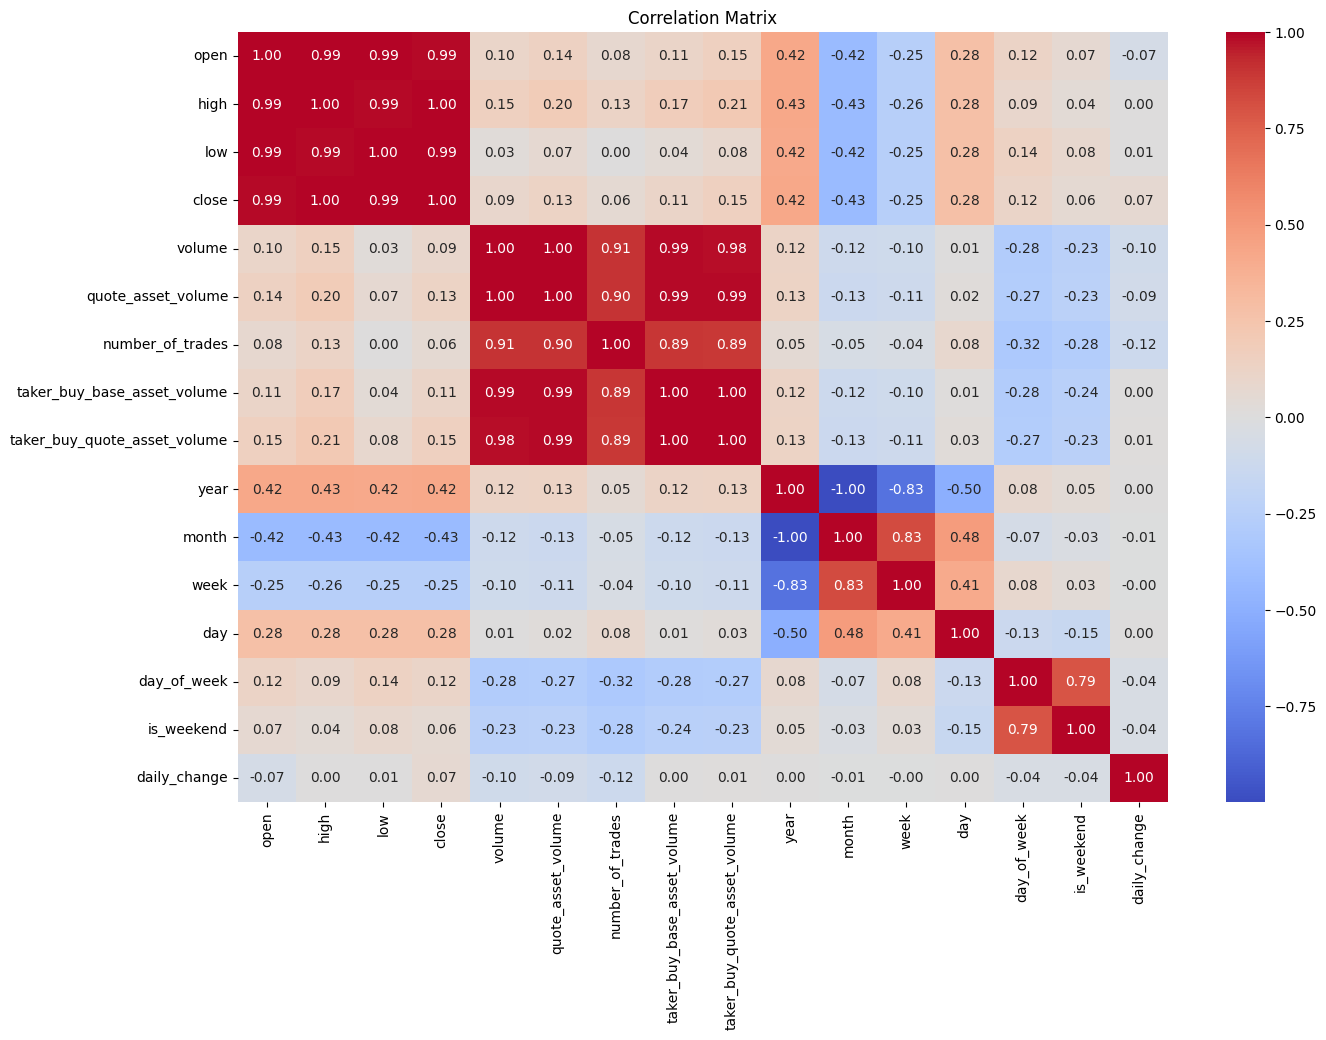

In [18]:
correlation_matrix = df.corr()

# Visualize using a heatmap
plt.figure(figsize=(15, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [19]:
# Compute correlation with the target column 'close'
# correlation_matrix = df.corr()
# close_correlation = correlation_matrix['close'].sort_values(ascending=False)

# Extract columns with correlation above 0.5
# selected_features = close_correlation[close_correlation > 0.2].index.tolist()
# df_selected = df[selected_features]

# Display selected features
# print("Selected features with correlation > 0.5:\n", selected_features)
# print(df_selected.head())
# df_selected.to_csv("bitcoin_selected_features2.csv", index=False)


Selected features with correlation > 0.5:
 ['close', 'high', 'low', 'open', 'year', 'day']
      close      high       low      open  year  day
0  93964.01  94305.61  93181.83  93186.34  2024   23
1  95191.81  95191.81  93911.50  93964.01  2024   23
2  94881.47  95509.09  94683.81  95191.80  2024   23
3  94550.22  94881.47  94131.11  94881.47  2024   24
4  94123.43  94672.00  94036.00  94550.23  2024   24


In [34]:
df1 = pd.read_csv('bitcoin_selected_features.csv')

In [38]:
df1.head()

,open,high,low,close,volume,quote_asset_volume,number_of_trades,taker_buy_base_asset_volume,taker_buy_quote_asset_volume,day,average_price
0,93186.34,94305.61,93181.83,93964.01,1407.12075,1.321943e+08,243203,715.63042,6.721563e+07,23,93743.720
1,93964.01,95191.81,93911.50,95191.81,1019.60575,9.645337e+07,152484,579.62294,5.483776e+07,23,94551.655
2,95191.80,95509.09,94683.81,94881.47,1067.72308,1.015573e+08,174942,571.49092,5.437752e+07,23,95096.450
3,94881.47,94881.47,94131.11,94550.22,955.84079,9.027902e+07,187102,449.36960,4.244027e+07,24,94506.290
4,94550.23,94672.00,94036.00,94123.43,567.58156,5.354935e+07,157351,268.15219,2.530346e+07,24,94354.000


In [35]:
df1 = df1.drop(columns=['year','month', 'week', 'is_weekend', 'daily_change','day_of_week'], axis=1)

KeyError: "['year', 'month', 'week', 'is_weekend', 'daily_change', 'day_of_week'] not found in axis"

In [37]:
df1['average_price'] = (df1['high'] + df1['low']) / 2

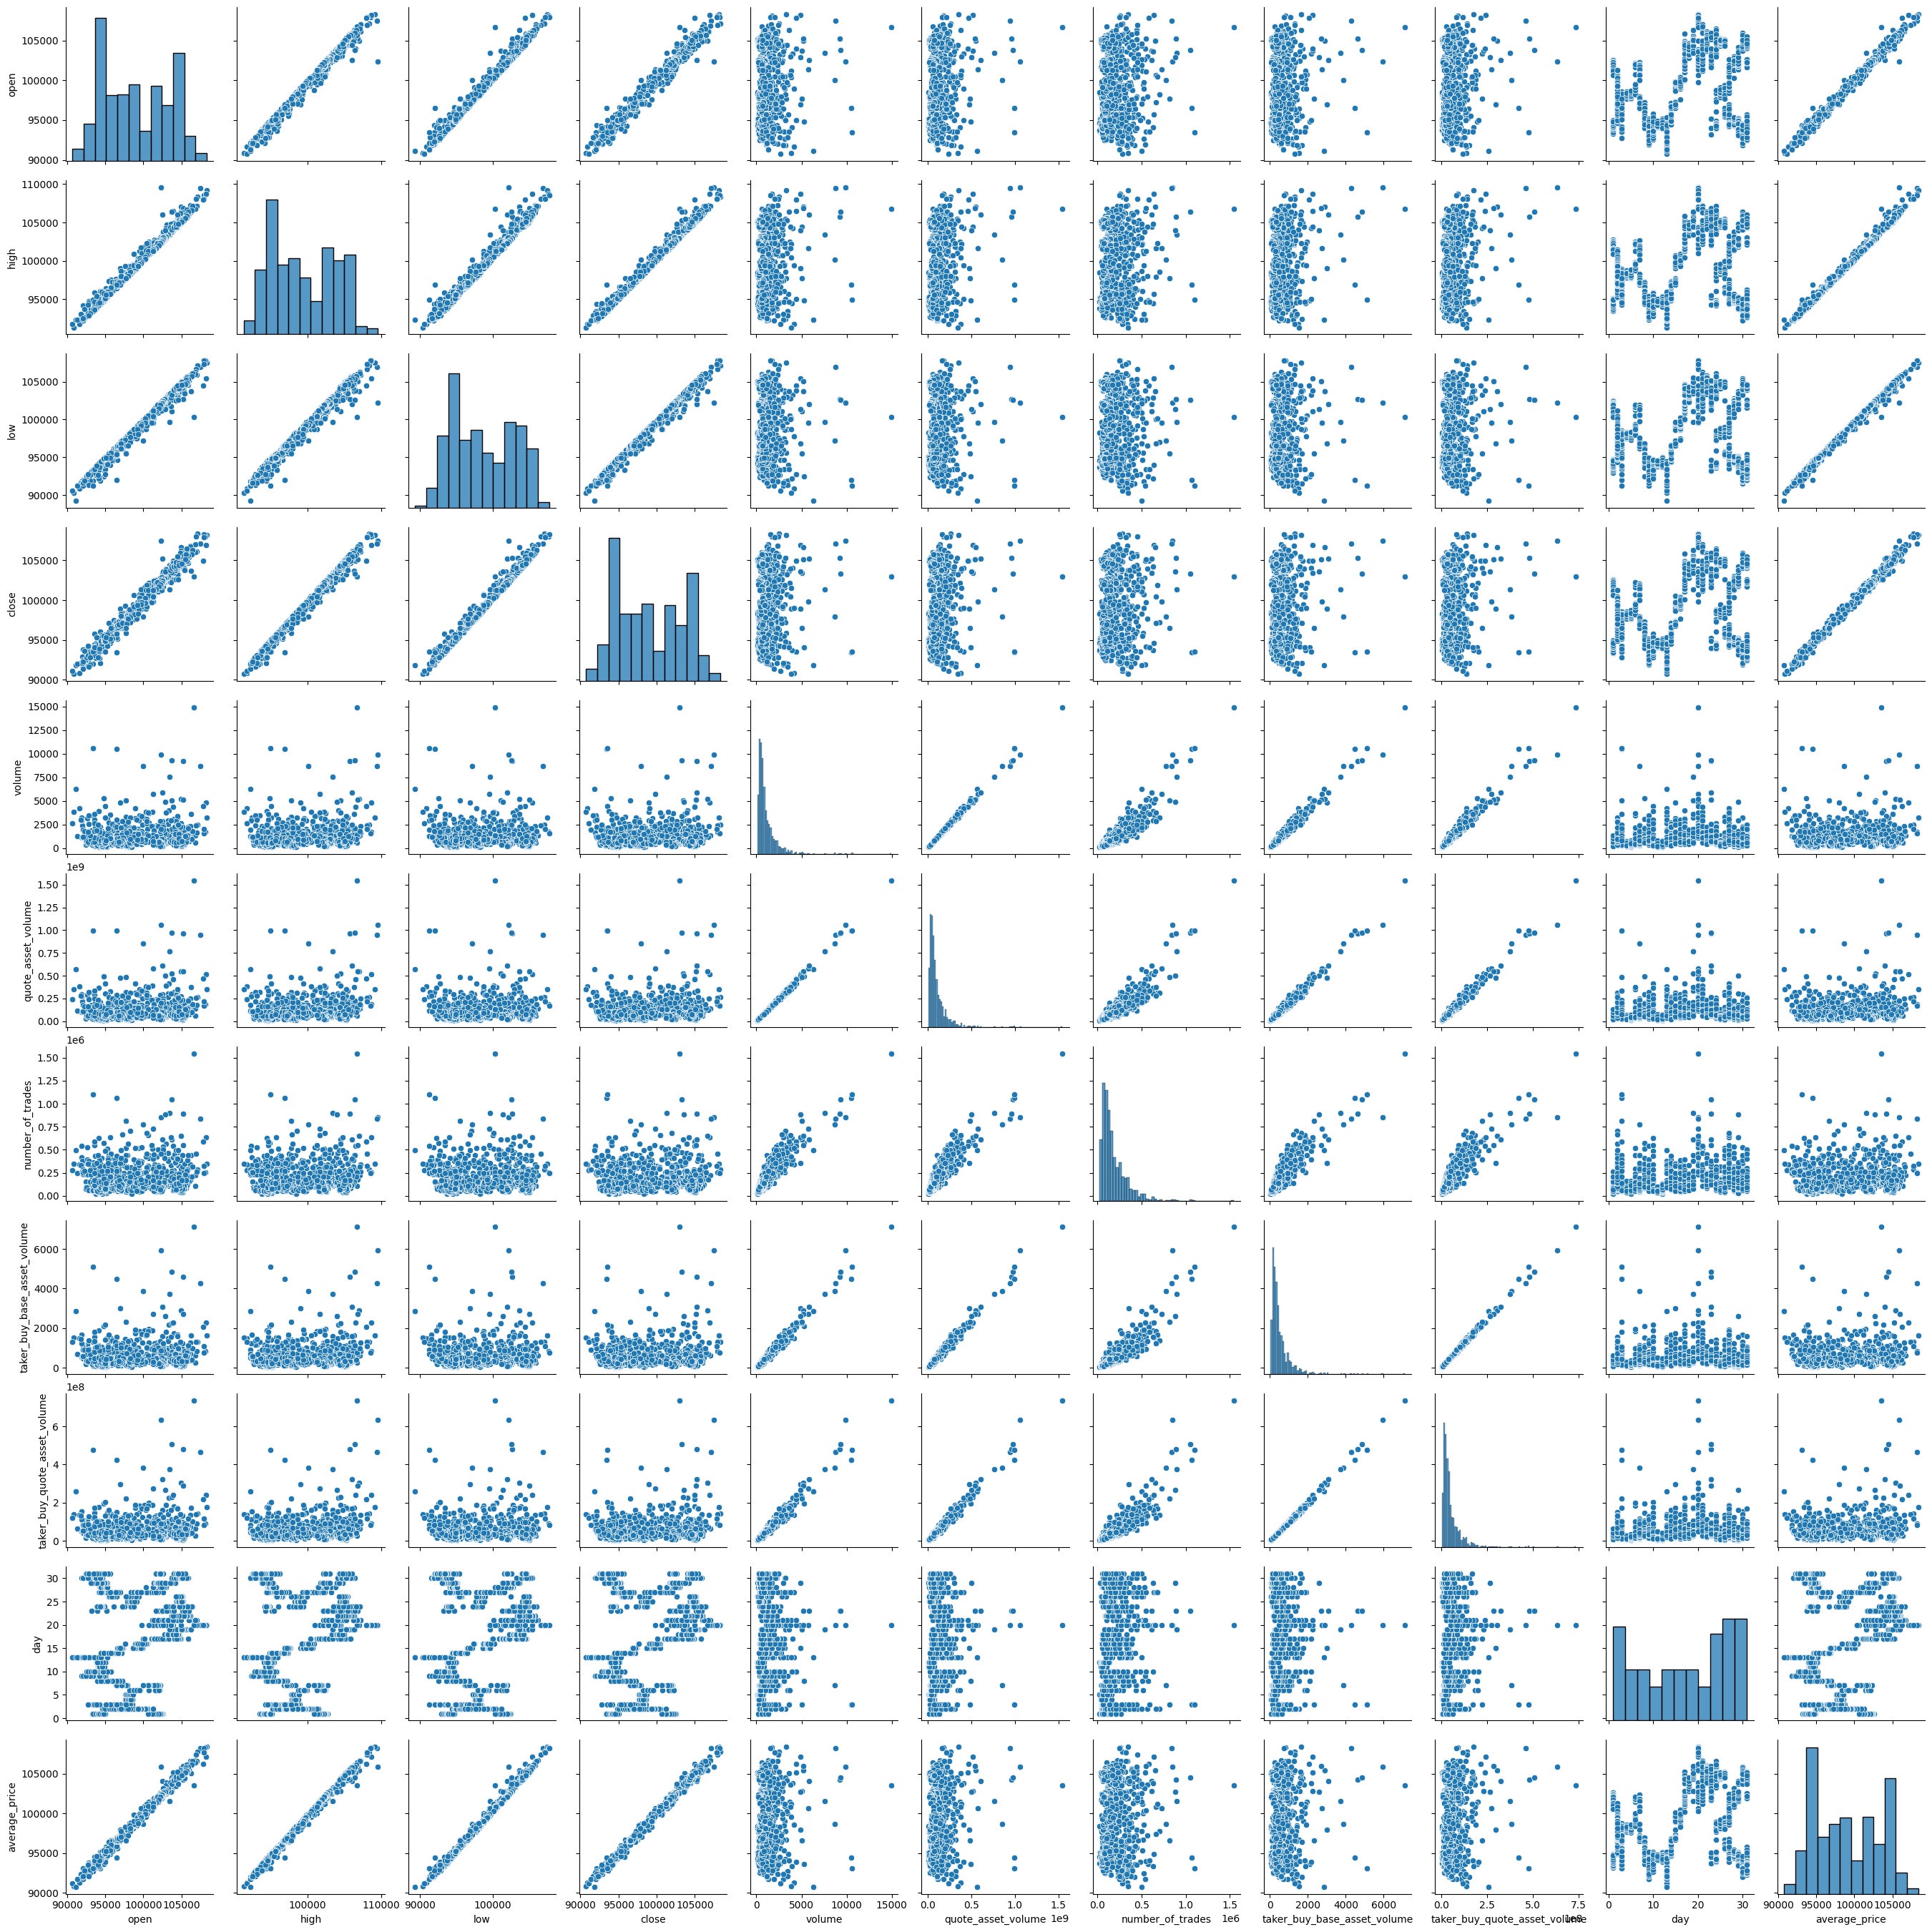

In [39]:
sns.pairplot(df1)

In [151]:
df1.head()

,open,high,low,close,volume,quote_asset_volume,number_of_trades,taker_buy_base_asset_volume,taker_buy_quote_asset_volume,day,average_price
0,93186.34,94305.61,93181.83,93964.01,1407.12075,1.321943e+08,243203,715.63042,6.721563e+07,23,93743.720
1,93964.01,95191.81,93911.50,95191.81,1019.60575,9.645337e+07,152484,579.62294,5.483776e+07,23,94551.655
2,95191.80,95509.09,94683.81,94881.47,1067.72308,1.015573e+08,174942,571.49092,5.437752e+07,23,95096.450
3,94881.47,94881.47,94131.11,94550.22,955.84079,9.027902e+07,187102,449.36960,4.244027e+07,24,94506.290
4,94550.23,94672.00,94036.00,94123.43,567.58156,5.354935e+07,157351,268.15219,2.530346e+07,24,94354.000


In [153]:
df1.isnull().sum()

open                            0
high                            0
low                             0
close                           0
volume                          0
quote_asset_volume              0
number_of_trades                0
taker_buy_base_asset_volume     0
taker_buy_quote_asset_volume    0
day                             0
average_price                   0
dtype: int64

In [97]:
# df['ma_5'] =  df['ma_5'].fillna(df['ma_5'].mean())
# df['ma_10'] = df['ma_10'].fillna(df['ma_10'].mean())
# df['ma_20'] = df['ma_20'].fillna(df['ma_20'].mean())
# df['lower_band'] = df['lower_band'].fillna(df['lower_band'].mean())
# df['upper_band'] = df['upper_band'].fillna(df['upper_band'].mean())

In [38]:
spearman_corr = df1.corr(method='spearman')
print(spearman_corr)

                                 close      high       low     ema_5  \
close                         1.000000  0.994599  0.994015  0.990861   
high                          0.994599  1.000000  0.989674  0.993324   
low                           0.994015  0.989674  1.000000  0.989877   
ema_5                         0.990861  0.993324  0.989877  1.000000   
open                          0.988597  0.993831  0.992404  0.994257   
ma_5                          0.985226  0.989445  0.985911  0.998238   
ema_10                        0.978877  0.983052  0.977915  0.995213   
ma_10                         0.969638  0.975110  0.968584  0.990002   
ma_20                         0.941335  0.947492  0.939601  0.964678   
lower_band                    0.911979  0.912890  0.916552  0.934134   
upper_band                    0.911533  0.922488  0.903662  0.933287   
rsi_14                        0.291287  0.272133  0.286529  0.232545   
taker_buy_quote_asset_volume  0.279123  0.322969  0.225022  0.28

In [25]:
df11 = pd.read_csv('bitcoin_selected_features.csv')
df11['target_close'] = df11['close'].shift(-1)

In [26]:
df11 = df11.dropna()

In [27]:
df11 = df11.drop(columns=['close'])

In [33]:
df11.head()

,open,high,low,volume,quote_asset_volume,number_of_trades,taker_buy_base_asset_volume,taker_buy_quote_asset_volume,day,target_close
0,93186.34,94305.61,93181.83,1407.12075,1.321943e+08,243203,715.63042,6.721563e+07,23,95191.81
1,93964.01,95191.81,93911.50,1019.60575,9.645337e+07,152484,579.62294,5.483776e+07,23,94881.47
2,95191.80,95509.09,94683.81,1067.72308,1.015573e+08,174942,571.49092,5.437752e+07,23,94550.22
3,94881.47,94881.47,94131.11,955.84079,9.027902e+07,187102,449.36960,4.244027e+07,24,94123.43
4,94550.23,94672.00,94036.00,567.58156,5.354935e+07,157351,268.15219,2.530346e+07,24,93961.45


In [28]:
X = df11.drop(columns=["target_close"])  
y = df11["target_close"]

# Chronological split (80% train, 20% test)
split_index = int(len(df11) * 0.8)
X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

# Scaling operation (Fit scaler on training set and transform both train and test sets)
# scaler = MinMaxScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)
# y_train_scaled = scaler.fit_transform(y_train.values.reshape(-1,1))
# y_test_scaled = scaler.transform(y_test.values.reshape(-1,1))



In [29]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [30]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)

Mean Absolute Error (MAE): 412.9384933673443
Mean Squared Error (MSE): 366206.2283014911
Root Mean Squared Error (RMSE): 605.1497569209552


<Axes: >

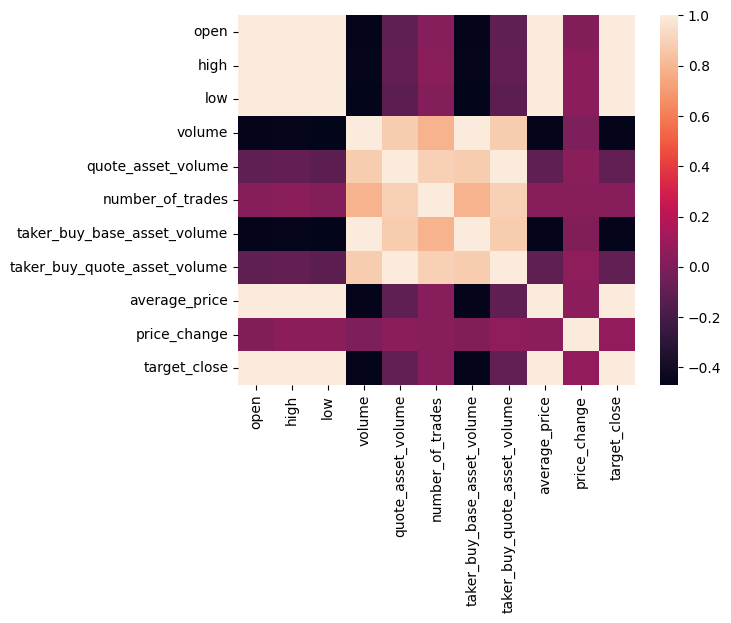

In [109]:
sns.heatmap(df.corr())

In [31]:
import pandas as pd

# Creating a DataFrame to compare actual vs. predicted values
comparison_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

# Display the first few rows
print(comparison_df.head())


      Actual      Predicted
0  105094.12  105229.084784
1  104990.75  105014.961698
2  104998.35  104984.386524
3  105030.40  104962.767885
4  104630.03  104980.823681


In [32]:
comparison_df["Difference"] = comparison_df["Actual"] - comparison_df["Predicted"]

print(comparison_df.head())


      Actual      Predicted  Difference
0  105094.12  105229.084784 -134.964784
1  104990.75  105014.961698  -24.211698
2  104998.35  104984.386524   13.963476
3  105030.40  104962.767885   67.632115
4  104630.03  104980.823681 -350.793681
